In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../data/tanzania.csv")
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [3]:
df["Country"] = "Tanzania"

In [4]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

In [5]:
df["Month"] = df["date"].dt.month

In [6]:
df = df.replace(-999, np.nan)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df = df.drop_duplicates()

In [9]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


In [10]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100
missing_percent

YEAR           0.0
DOY            0.0
T2M            0.0
T2M_MAX        0.0
T2M_MIN        0.0
T2M_RANGE      0.0
PRECTOTCORR    0.0
RH2M           0.0
WS2M           0.0
WS2M_MAX       0.0
PS             0.0
QV2M           0.0
Country        0.0
date           0.0
Month          0.0
dtype: float64

In [11]:
missing_percent[missing_percent > 5]

Series([], dtype: float64)

In [12]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)

outliers = (z_scores.abs() > 3)
outliers_count = outliers.sum()

outliers_count

T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64

In [13]:
for col in cols:
    upper = df[col].mean() + 3 * df[col].std()
    lower = df[col].mean() - 3 * df[col].std()
    df[col] = np.clip(df[col], lower, upper)

In [14]:
df= df.ffill()

In [15]:
df = df.dropna()

In [16]:
df.to_csv("../data/tanzania_clean.csv", index=False)

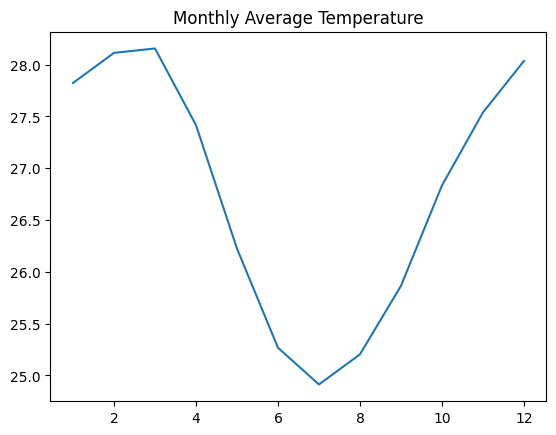

In [17]:
monthly_temp = df.groupby("Month")["T2M"].mean()

plt.plot(monthly_temp.index, monthly_temp.values)
plt.title("Monthly Average Temperature")
plt.show()

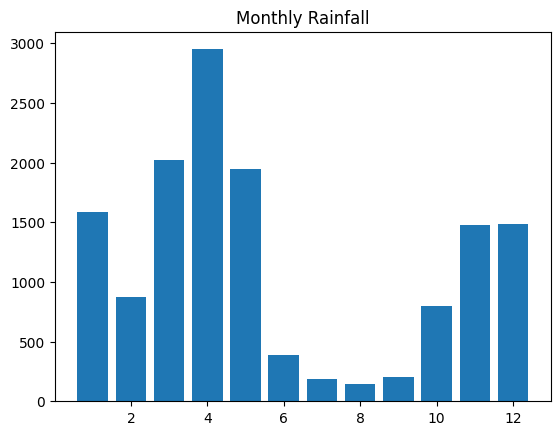

In [18]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

plt.bar(monthly_rain.index, monthly_rain.values)
plt.title("Monthly Rainfall")
plt.show()

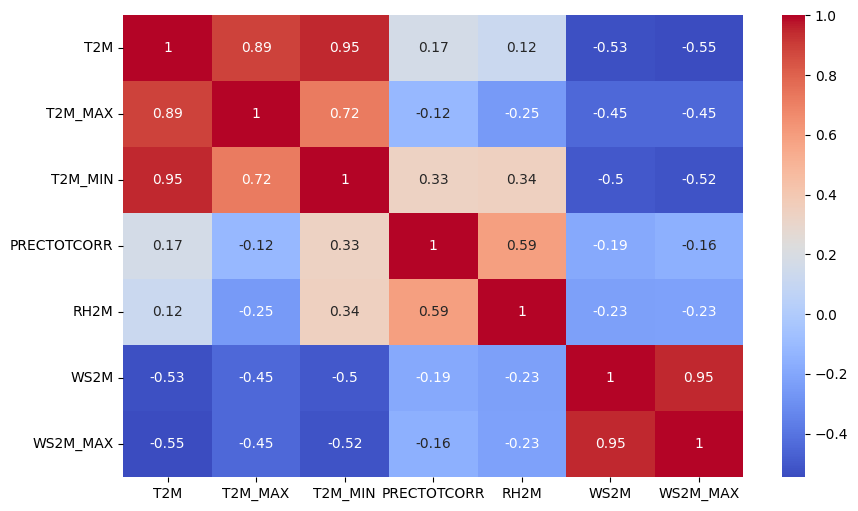

In [20]:
plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap="coolwarm")
plt.show()

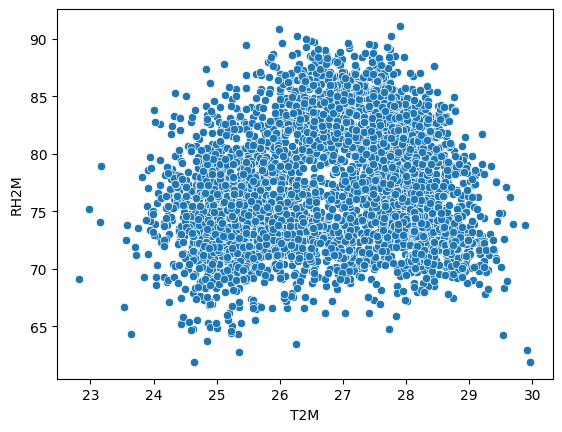

In [21]:
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.show()

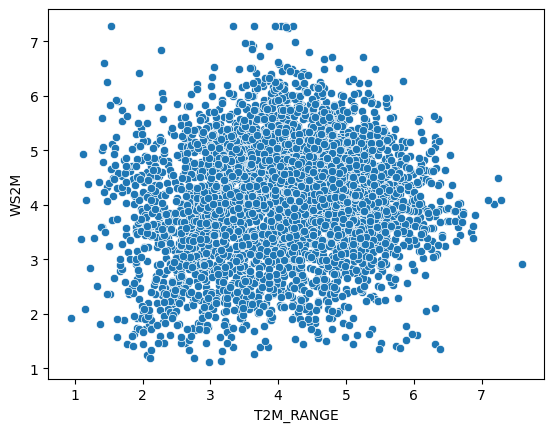

In [22]:
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.show()

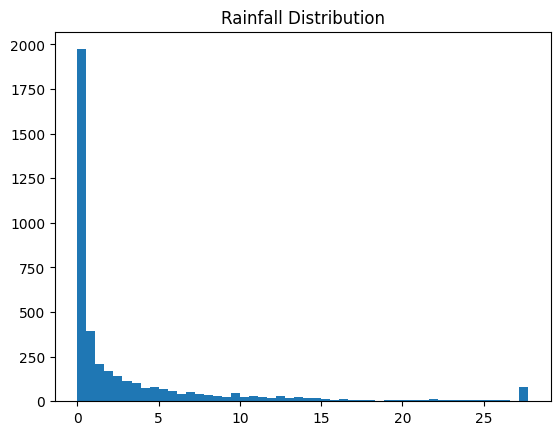

In [23]:
plt.hist(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

# Climate Analysis Report 

## Temperature Trends
The **Monthly Average Temperature** profile indicates a high-temperature region with a sharp mid-year cooling period:
* **Peak Period:** Temperatures are highest in the first quarter, reaching a maximum in **March (Month 3)** at approximately **28.2°C**.
* **The Dip:** There is a steep decline through the second quarter, hitting an annual low in **July (Month 7)** at roughly **24.9°C**.
* **Recovery:** A significant warming trend follows, with temperatures climbing back to **28.0°C** by December.

## Rainfall Patterns
The **Monthly Rainfall** bar chart shows a heavily front-loaded precipitation pattern, suggestive of a strong early-year monsoon:
* **Major Peak:** Rainfall surges to its highest level in **April (Month 4)**, nearing **3,000 units**.
* **Dry Stretch:** The middle of the year (June through September) is exceptionally dry, with August recording the lowest rainfall.
* **Secondary Surge:** Rainfall increases again in the final quarter, stabilizing around **1,500 units** in November and December.
* **Distribution:** The **Rainfall Distribution** histogram shows a heavy concentration of low-rain days (0–5 units) but includes a distinct "spike" of extreme events at the **27-unit** mark, representing heavy storm occurrences.

## Strongest Correlations
The **Correlation Heatmap** reveals the primary physical drivers of this climate:
* **Wind Speed Coupling:** The strongest positive correlation in the dataset is between **WS2M (Wind Speed)** and **WS2M_MAX** (**0.95**). This suggests that average wind speeds and maximum gusts move in almost perfect lockstep.
* **Temperature Consistency:** Average temperature (**T2M**) is almost perfectly correlated with the daily minimum temperature (**0.95**), indicating that nighttime cooling is the dominant factor in determining the daily average.
* **Rainfall and Humidity:** There is a solid positive correlation (**0.59**) between **PRECTOTCORR** (Precipitation) and **RH2M** (Relative Humidity), confirming that rainy months are significantly more humid.

## Anomalies and Observations
* **Negative Wind-Temperature Correlation:** Unlike some regions, this data shows a **negative correlation (-0.53)** between **T2M** and **WS2M**. This implies that the hottest months (early year) are actually the least windy, whereas the cooler months see higher wind activity.
* **Humidity Variance:** The scatter plot for **RH2M vs. T2M** shows a very wide "cloud" of data points. While there is a slight negative trend, humidity remains high across a wide range of temperatures, likely due to proximity to a moisture source (e.g., a coastline).
* **Wind and Temperature Range:** The scatter plot for **WS2M vs. T2M_RANGE** shows no strong linear relationship, suggesting that wind speeds in this region are driven by large-scale atmospheric pressure systems rather than local daily temperature fluctuations.

---
**Summary Statement:** > *“Temperature and wind speed show a negative correlation, meaning the hottest periods of the year are the calmest. The region is characterized by an intense rainfall peak in April, which coincides with high relative humidity.”*